In [1]:
from bbq.field import Field
from bbq.polynomial import Monomial
from bbq.bbq_code import BivariateBicycle
from bbq.circuit import construct_sm_circuit, generate_noisy_circuit, simulate_x_circuit, generate_single_error_circuits, build_hx_dict, build_hz_dict, build_hx_eff, build_hz_eff, construct_decoding_matrix
from bbq.simulation import process_results
from bbq.decoder import RelayBP, BPOSD, BP, ProdRelayBP, SmoothRelayBP, DoubleRelayBP, StrawBP

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.sparse import coo_matrix, hstack
from relay_bp import RelayDecoderF32
import numba


## Toric 3x3

BP succeeded: False
RelayBP succeeded: True
StrawBP succeeded: True


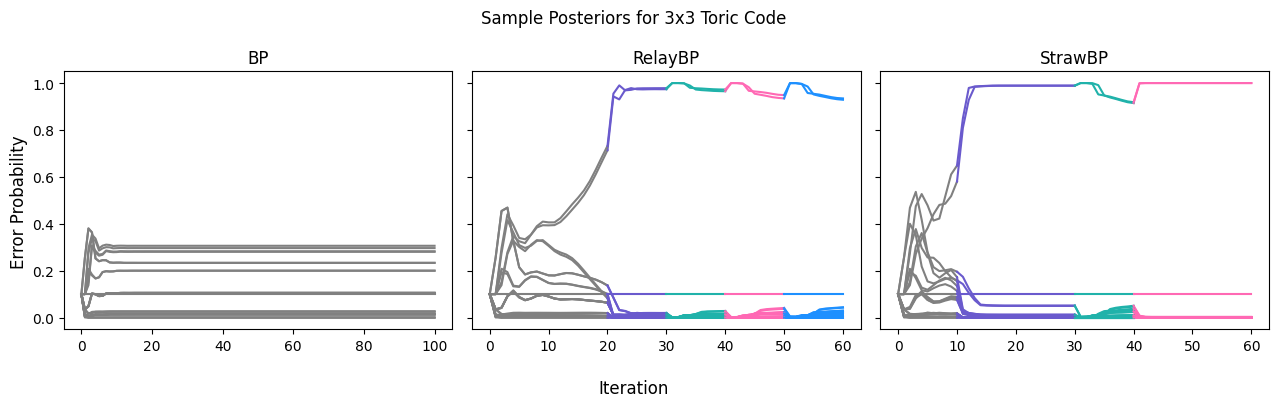

In [90]:
# SETUP

# field = Field(2)
# x, y = Monomial(field, 'x'), Monomial(field, 'y')
# a, b = 1-x, 1-y
# bb = BivariateBicycle(a, b, 5, 5, 1)
# # bb.draw()
# h = bb.hx
# priors = np.array([[0.99, 0.01] for _ in range(h.shape[1])], dtype=float)
# error = np.zeros(h.shape[1])
# error[0] = 1
# error[25] = 1
# # error[70] = 1
# syndrome = (h @ error) % field.p

# field = Field(2)
# h = np.array([[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#               [1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
#               [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
#               [0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0],
#               [0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0],
#               [0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0],
#               [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
#               [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1],
#               [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1]
#               ])
# priors = np.array([[0.9, 0.1] for _ in range(h.shape[1])], dtype=float)
# syndrome = np.array([1, 0, 0, 0, 0, 0, 0, 0, 1])

# h = np.array([[1, 1, 0, 0, 0, 0, 0, 0, 0],
#               [0, 1, 1, 0, 1, 1, 0, 0, 0],
#               [0, 0, 0, 1, 1, 0, 1, 1, 0],
#               [0, 0, 0, 0, 0, 0, 0, 1, 1]
#               ])
# priors = np.array([[0.95, 0.05] for _ in range(h.shape[1])], dtype=float)
# syndrome = np.array([1, 0, 1, 0])

h = np.zeros((12, 25))
row, col = [0, 0, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6,6, 7, 7, 7, 7, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 11, 11], [0, 1, 2, 3, 1, 2, 6, 7, 3, 4, 8, 9, 5, 6, 10, 11, 7, 8, 12, 13, 11, 12, 16, 17, 13, 14, 18, 19, 15, 16, 20, 21, 17, 18, 22, 23, 21, 22, 22, 23]
for i in range(len(row)):
    h[row[i], col[i]] = 1
priors = np.array([[0.9, 0.1] for _ in range(h.shape[1])], dtype=float)
syndrome = np.array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])

c = 0.2
w = 0.4

bp = BP(field, h, priors, 100)

mem_weight = np.zeros((h.shape[1], field.p, 5))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 5 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 5, mem_weight)

iter_bp = 20
iter_mem = 10
strawbp = StrawBP(field, h, priors, iter_bp, iter_mem, 3, 2, 1, c, w)

# SAMPLE

error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, posteriors_strawbp = strawbp.decode(syndrome, debug=True, metric=True)
posteriors_strawbp = np.array(posteriors_strawbp)
print(f"StrawBP succeeded: {success}")

# PLOT

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(13, 4), sharey=True)
fig.suptitle('Sample Posteriors for 3x3 Toric Code')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0].set_title('BP')
axs[1].set_title('RelayBP')
axs[2].set_title('StrawBP')

colours = ["gray", "slateblue", "lightseagreen", "hotpink", "dodgerblue", "red", "green", "blue", "black", "gray"]

for qubit in range(posteriors_bp.shape[1]):
    # axs[0].plot(bp_post[:, qubit], color='gray')
    axs[0].plot(posteriors_bp[:, qubit, 1], color='gray')

    start = 0
    its = len(posteriors_relay)
    if its <= 21:
        iterations = [its]
    else:
        iterations = [21]
        its -= 21
        for _ in range(its // 10):
            iterations.append(10)
            its -= 10
        if its:
            iterations.append(its)

    for ind, iteration in enumerate(iterations):
        axs[1].plot(np.arange(max(start-1, 0), start+iteration), posteriors_relay[max(start-1, 0):start+iteration, qubit, 1], color=colours[ind])
        start += iteration

    start = 0
    its = len(posteriors_strawbp)
    max_its = [iter_mem, iter_bp]
    i = 0
    iterations = []
    while its > 0:
        if its < max_its[i]:
            iterations.append(its)
            its = 0
        else:
            iterations.append(max_its[i])
            its -= max_its[i]
        i+=1
        i%=2
    iterations[0] += 1
    iterations.pop(-1)
    for ind, iteration in enumerate(iterations):
        axs[2].plot(np.arange(max(start-1, 0), start+iteration), posteriors_strawbp[max(start-1, 0):start+iteration, qubit, 1], color=colours[ind])
        start += iteration

fig.tight_layout()


In [ ]:
relaybp.solutions_lh


array([-7.02846205,        -inf,        -inf])

In [ ]:
strawbp.solutions_lh


array([-7.02846205,        -inf,        -inf])

In [ ]:
np.nonzero(h[0])


(array([ 0,  7, 49, 50]),)

In [ ]:
bp_post = posteriors_bp[:, :, 1]


In [ ]:
relay_post = posteriors_relay[:, :, 1]


## Single Small Loop

In [2]:
field = Field(2)
h = (np.array([[1, -1],
              [-1, 1]])) % field.p
priors = np.array([[0.9, 0.1],
                   [0.9, 0.1]], dtype=float)
# priors = np.array([[0.9, 0.05, 0.05],
#                    [0.9, 0.05, 0.05]], dtype=float)
syndrome = (h @ np.array([1, 0])) % field.p
loopsize=1

c = 0.2
w = 0.5

bp = BP(field, h, priors, 100)
membp = RelayBP(field, h, priors, 50, 50, 1, 1, 0.2*np.ones((h.shape[1], field.p, 1)))

mem_weight = np.zeros((h.shape[1], field.p, 4))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 4 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 4, mem_weight)

loopmembp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)) / loopsize)
prodmembp = ProdRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))
smoothmembp = SmoothRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), loopsize)
doublemembp = DoubleRelayBP(field, h, priors, 50, 50, 1, 1, 0.1*np.ones((h.shape[1], field.p, 1)), 0.9*np.ones((h.shape[1], field.p, 1)), loopsize)
doublerelaybp = DoubleRelayBP(field, h, priors, 10, 20, 3, 4, mem_weight, 2*np.ones((h.shape[1], field.p, 4)), loopsize)

rmem_weight = np.zeros((h.shape[1], field.p, 2))
rmem_weight[:, :, 0] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p))
randbp = RelayBP(field, h, priors, 40, 10, 3, 2, rmem_weight)
strawbp = StrawBP(field, h, priors, 20, 10, 3, 2, 1, c, w)


In [4]:
error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, _, posteriors_mem = membp.decode(syndrome, debug=True, metric=True)
posteriors_mem = np.array(posteriors_mem)
print(f"MemBP succeeded: {success}")

error, success, _, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, _, posteriors_loopmem = loopmembp.decode(syndrome, debug=True, metric=True)
posteriors_loopmem = np.array(posteriors_loopmem)
print(f"LoopMemBP succeeded: {success}")

error, success, _, posteriors_prodmem = prodmembp.decode(syndrome, debug=True, metric=True)
posteriors_prodmem = np.array(posteriors_prodmem)
print(f"ProdMemBP succeeded: {success}")

error, success, _, posteriors_smoothmem = smoothmembp.decode(syndrome, debug=True, metric=True)
posteriors_smoothmem = np.array(posteriors_smoothmem)
print(f"SmoothMemBP succeeded: {success}")

error, success, _, posteriors_doublemem = doublemembp.decode(syndrome, debug=True, metric=True)
posteriors_doublemem = np.array(posteriors_doublemem)
print(f"DoubleMemBP succeeded: {success}")

error, success, _, posteriors_doublerelay = doublerelaybp.decode(syndrome, debug=True, metric=True)
posteriors_doublerelay = np.array(posteriors_doublerelay)
print(f"DoubleRelayBP succeeded: {success}")

error, success, _, posteriors_strawbp = strawbp.decode(syndrome, debug=True, metric=True)
posteriors_strawbp = np.array(posteriors_strawbp)
print(f"StrawBP succeeded: {success}")


BP succeeded: False
MemBP succeeded: False
RelayBP succeeded: True
LoopMemBP succeeded: False
ProdMemBP succeeded: False
SmoothMemBP succeeded: False
DoubleMemBP succeeded: False
DoubleRelayBP succeeded: True
StrawBP succeeded: True


ValueError: x and y must have same first dimension, but have shapes (100,) and (101,)

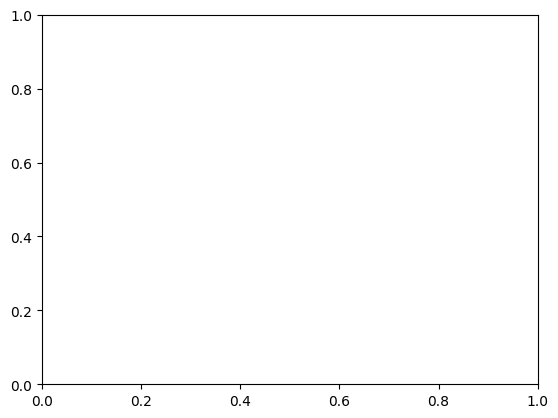

In [ ]:
qubit = 0
t = np.arange(100)
sp = np.fft.fft(posteriors_bp[:, qubit, 0])
freq = np.fft.fftfreq(t.shape[-1])
_ = plt.plot(freq, sp.real, freq, sp.imag)
plt.show()


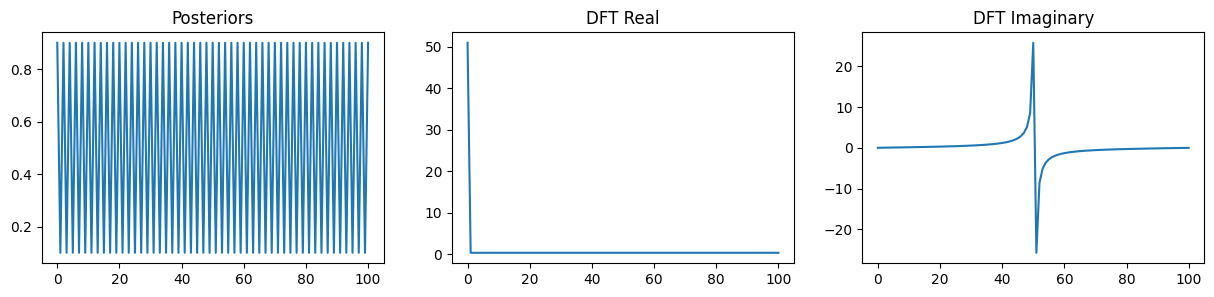

In [ ]:
qubit = 0
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 3))

axs[0].plot(posteriors_bp[:, qubit, 0])
axs[1].plot(np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).real)
axs[2].plot(np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).imag)

axs[0].set_title("Posteriors")
axs[1].set_title("DFT Real")
axs[2].set_title("DFT Imaginary");


In [ ]:
np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).imag


array([ 3.49720253e-15,  1.24459652e-02,  2.49160527e-02,  3.74345718e-02,
        5.00262100e-02,  6.27162294e-02,  7.55306729e-02,  8.84965844e-02,
        1.01642246e-01,  1.14997435e-01,  1.28593715e-01,  1.42464748e-01,
        1.56646663e-01,  1.71178458e-01,  1.86102472e-01,  2.01464926e-01,
        2.17316547e-01,  2.33713311e-01,  2.50717297e-01,  2.68397721e-01,
        2.86832147e-01,  3.06107961e-01,  3.26324130e-01,  3.47593359e-01,
        3.70044720e-01,  3.93826903e-01,  4.19112257e-01,  4.46101858e-01,
        4.75031931e-01,  5.06182054e-01,  5.39885765e-01,  5.76544433e-01,
        6.16645613e-01,  6.60787705e-01,  7.09713572e-01,  7.64357167e-01,
        8.25909451e-01,  8.95913612e-01,  9.76405979e-01,  1.07013046e+00,
        1.18087550e+00,  1.31402389e+00,  1.47749059e+00,  1.68341093e+00,
        1.95138706e+00,  2.31527593e+00,  2.83902807e+00,  3.65967845e+00,
        5.13351529e+00,  8.56692439e+00,  2.57173651e+01, -2.57173651e+01,
       -8.56692439e+00, -

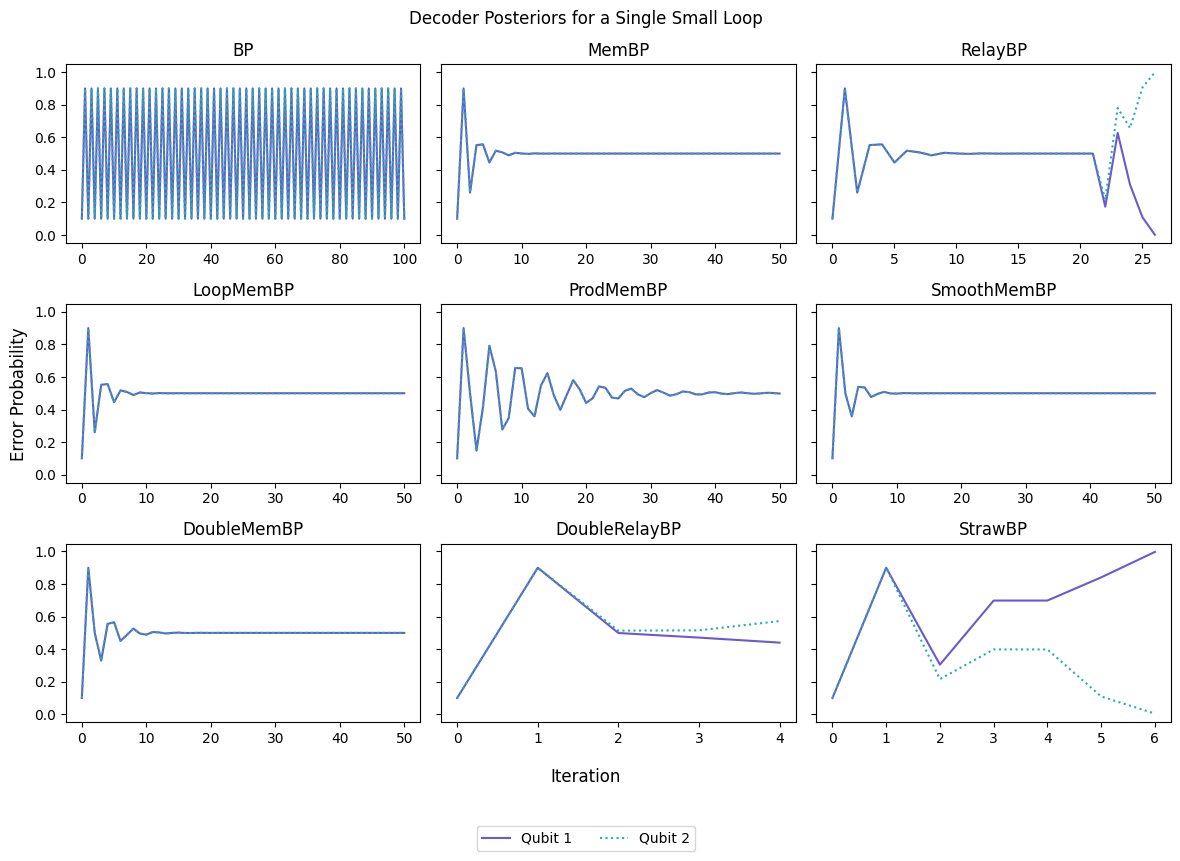

In [5]:
colours = ["slateblue", "lightseagreen", "hotpink", "dodgerblue"]
linestyles = ['-', ':']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8), sharey=True)
fig.suptitle('Decoder Posteriors for a Single Small Loop')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0, 0].set_title('BP')
axs[0, 1].set_title('MemBP')
axs[0, 2].set_title('RelayBP')
axs[1, 0].set_title('LoopMemBP')
axs[1, 1].set_title('ProdMemBP')
axs[1, 2].set_title('SmoothMemBP')
axs[2, 0].set_title('DoubleMemBP')
axs[2, 1].set_title('DoubleRelayBP')
axs[2, 2].set_title('StrawBP')

for qubit in range(posteriors_bp.shape[1]):
    axs[0, 0].plot(posteriors_bp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit], label = f"Qubit {qubit+1}")
    axs[0, 1].plot(posteriors_mem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[0, 2].plot(posteriors_relay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 0].plot(posteriors_loopmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 1].plot(posteriors_prodmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 2].plot(posteriors_smoothmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 0].plot(posteriors_doublemem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 1].plot(posteriors_doublerelay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 2].plot(posteriors_strawbp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])

fig.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()


## Single Medium Loop

In [25]:
field = Field(2)
h = (np.array([[-1, 1, 0, 0],
              [0, -1, -1, 0],
              [0, 0, 1, -1],
              [1, 0, 0, 1]])) % field.p
priors = np.array([[0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1]], dtype=float)
# priors = np.array([[0.9, 0.05, 0.05],
#                    [0.9, 0.05, 0.05],
#                    [0.9, 0.05, 0.05],
#                    [0.9, 0.05, 0.05]], dtype=float)
syndrome = (h @ np.array([0, 1, 1, 0])) % field.p
loopsize=2

c = 0.2
w = 0.5

bp = BP(field, h, priors, 99)
membp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))

mem_weight = np.zeros((h.shape[1], field.p, 4))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 4 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 4, mem_weight)

loopmembp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)) / loopsize)
prodmembp = ProdRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))
smoothmembp = SmoothRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), loopsize)
doublemembp = DoubleRelayBP(field, h, priors, 50, 50, 1, 1, 0.2*np.ones((h.shape[1], field.p, 1)), 2*np.ones((h.shape[1], field.p, 1)), loopsize)
doublerelaybp = DoubleRelayBP(field, h, priors, 10, 20, 3, 4, mem_weight, 2*np.ones((h.shape[1], field.p, 4)), loopsize)

rmem_weight = np.zeros((h.shape[1], field.p, 2))
rmem_weight[:, :, 0] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p))
randbp = RelayBP(field, h, priors, 40, 10, 3, 2, rmem_weight)


In [26]:
error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, _, posteriors_mem = membp.decode(syndrome, debug=True, metric=True)
posteriors_mem = np.array(posteriors_mem)
print(f"MemBP succeeded: {success}")

error, success, _, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, _, posteriors_loopmem = loopmembp.decode(syndrome, debug=True, metric=True)
posteriors_loopmem = np.array(posteriors_loopmem)
print(f"LoopMemBP succeeded: {success}")

error, success, _, posteriors_prodmem = prodmembp.decode(syndrome, debug=True, metric=True)
posteriors_prodmem = np.array(posteriors_prodmem)
print(f"ProdMemBP succeeded: {success}")

error, success, _, posteriors_smoothmem = smoothmembp.decode(syndrome, debug=True, metric=True)
posteriors_smoothmem = np.array(posteriors_smoothmem)
print(f"SmoothMemBP succeeded: {success}")

error, success, _, posteriors_doublemem = doublemembp.decode(syndrome, debug=True, metric=True)
posteriors_doublemem = np.array(posteriors_doublemem)
print(f"DoubleMemBP succeeded: {success}")

error, success, _, posteriors_doublerelay = doublerelaybp.decode(syndrome, debug=True, metric=True)
posteriors_doublerelay = np.array(posteriors_doublerelay)
print(f"DoubleRelayBP succeeded: {success}")

error, success, _, posteriors_randbp = randbp.decode(syndrome, debug=True, metric=True)
posteriors_randbp = np.array(posteriors_randbp)
print(f"RandBP succeeded: {success}")


BP succeeded: False
MemBP succeeded: False
RelayBP succeeded: True
LoopMemBP succeeded: False
ProdMemBP succeeded: False
SmoothMemBP succeeded: False
DoubleMemBP succeeded: False
DoubleRelayBP succeeded: True
RandBP succeeded: True


/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:516: RuntimeWarning: invalid value encountered in divide
  sub_posteriors / np.sum(sub_posteriors, axis=1)[:, np.newaxis]
/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:537: RuntimeWarning: invalid value encountered in divide
  posteriors /= np.sum(posteriors, axis=1)[:, np.newaxis]
/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:219: RuntimeWarning: invalid value encountered in divide
  sub_convolutions = sub_convolutions / convolution


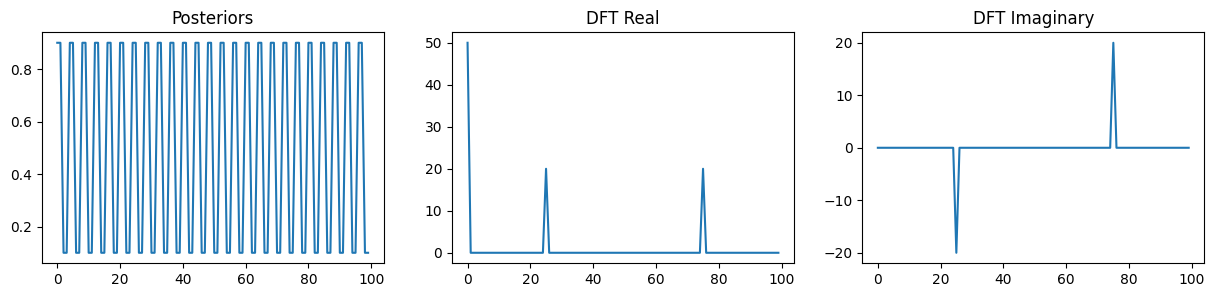

In [ ]:
qubit = 0
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 3))

axs[0].plot(posteriors_bp[:, qubit, 0])
axs[1].plot(np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).real)
axs[2].plot(np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).imag)

axs[0].set_title("Posteriors")
axs[1].set_title("DFT Real")
axs[2].set_title("DFT Imaginary");


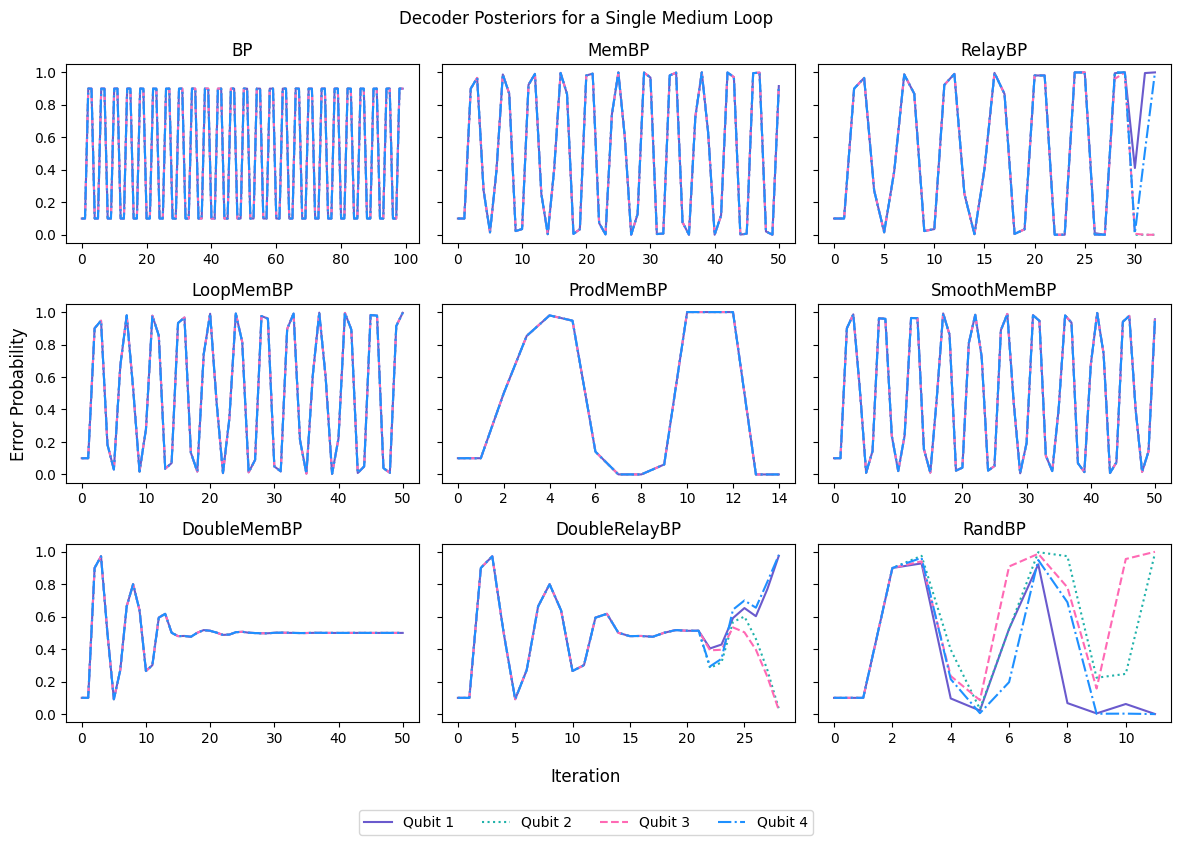

In [27]:
colours = ["slateblue", "lightseagreen", "hotpink", "dodgerblue"]
linestyles = ['-', ':', '--', '-.']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8), sharey=True)
fig.suptitle('Decoder Posteriors for a Single Medium Loop')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0, 0].set_title('BP')
axs[0, 1].set_title('MemBP')
axs[0, 2].set_title('RelayBP')
axs[1, 0].set_title('LoopMemBP')
axs[1, 1].set_title('ProdMemBP')
axs[1, 2].set_title('SmoothMemBP')
axs[2, 0].set_title('DoubleMemBP')
axs[2, 1].set_title('DoubleRelayBP')
axs[2, 2].set_title('RandBP')

for qubit in range(posteriors_bp.shape[1]):
    axs[0, 0].plot(posteriors_bp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit], label = f"Qubit {qubit+1}")
    axs[0, 1].plot(posteriors_mem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[0, 2].plot(posteriors_relay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 0].plot(posteriors_loopmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 1].plot(posteriors_prodmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 2].plot(posteriors_smoothmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 0].plot(posteriors_doublemem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 1].plot(posteriors_doublerelay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 2].plot(posteriors_randbp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])

fig.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()


## Single Large Loop

In [ ]:
field = Field(2)
h = (np.array([[1, 1, 0, 0, 0, 0],
              [0, 1, 1, 0, 0, 0],
              [0, 0, 1, 1, 0, 0],
              [0, 0, 0, 1, 1, 0],
              [0, 0, 0, 0, 1, 1],
              [1, 0, 0, 0, 0, 1]])) % field.p
priors = np.array([[0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1]], dtype=float)
syndrome = (h @ np.array([0, 1, 1, 1, 0, 0])) % field.p
loopsize=3

c = 0.2
w = 0.5

bp = BP(field, h, priors, 104)
membp = RelayBP(field, h, priors, 50, 50, 1, 1, 0.2*np.ones((h.shape[1], field.p, 1)))

mem_weight = np.zeros((h.shape[1], field.p, 4))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 4 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 4, mem_weight)

loopmembp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)) / loopsize)
prodmembp = ProdRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))
smoothmembp = SmoothRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), loopsize)
doublemembp = DoubleRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), 1.5*np.ones((h.shape[1], field.p, 1)), loopsize)
doublerelaybp = DoubleRelayBP(field, h, priors, 10, 20, 3, 4, mem_weight, 2*np.ones((h.shape[1], field.p, 4)), loopsize)

rmem_weight = np.zeros((h.shape[1], field.p, 2))
rmem_weight[:, :, 0] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p))
randbp = RelayBP(field, h, priors, 40, 10, 3, 2, rmem_weight)


In [29]:
rustrelaybp = RelayDecoderF32(h, error_priors=priors[:, 1], gamma0=c, pre_iter=20, num_sets=3, set_max_iter=10, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)
x_syndrome_history = syndrome.astype(np.uint8)
guessed_error = rustrelaybp.decode(x_syndrome_history)


In [171]:
guessed_error


array([0, 1, 1, 1, 0, 0], dtype=uint8)

In [30]:
error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, _, posteriors_mem = membp.decode(syndrome, debug=True, metric=True)
posteriors_mem = np.array(posteriors_mem)
print(f"MemBP succeeded: {success}")

error, success, _, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, _, posteriors_loopmem = loopmembp.decode(syndrome, debug=True, metric=True)
posteriors_loopmem = np.array(posteriors_loopmem)
print(f"LoopMemBP succeeded: {success}")

error, success, _, posteriors_prodmem = prodmembp.decode(syndrome, debug=True, metric=True)
posteriors_prodmem = np.array(posteriors_prodmem)
print(f"ProdMemBP succeeded: {success}")

error, success, _, posteriors_smoothmem = smoothmembp.decode(syndrome, debug=True, metric=True)
posteriors_smoothmem = np.array(posteriors_smoothmem)
print(f"SmoothMemBP succeeded: {success}")

error, success, _, posteriors_doublemem = doublemembp.decode(syndrome, debug=True, metric=True)
posteriors_doublemem = np.array(posteriors_doublemem)
print(f"DoubleMemBP succeeded: {success}")

error, success, _, posteriors_doublerelay = doublerelaybp.decode(syndrome, debug=True, metric=True)
posteriors_doublerelay = np.array(posteriors_doublerelay)
print(f"DoubleRelayBP succeeded: {success}")

error, success, _, posteriors_randbp = randbp.decode(syndrome, debug=True, metric=True)
posteriors_randbp = np.array(posteriors_randbp)
print(f"RandBP succeeded: {success}")


BP succeeded: False
MemBP succeeded: False
RelayBP succeeded: False
LoopMemBP succeeded: False
ProdMemBP succeeded: False
SmoothMemBP succeeded: False
DoubleMemBP succeeded: False
DoubleRelayBP succeeded: True
RandBP succeeded: True


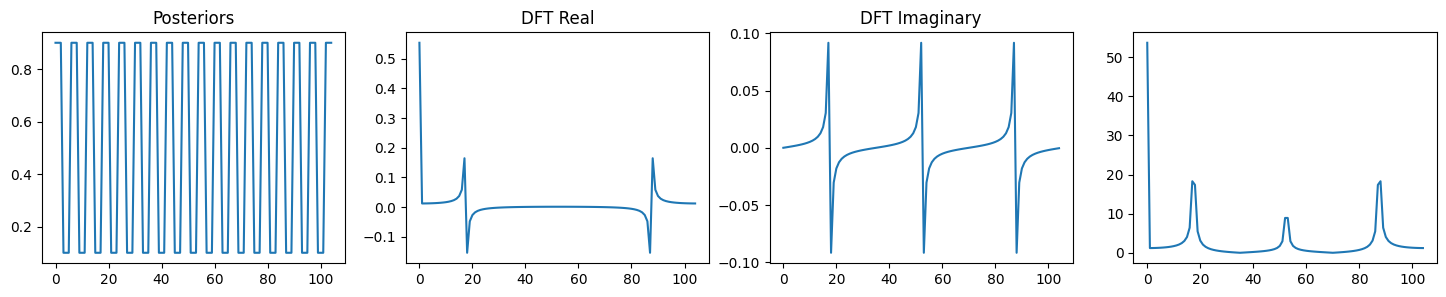

In [ ]:
qubit = 3
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(18, 3))

axs[0].plot(posteriors_bp[:, qubit, 0])
axs[1].plot(np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).real/97)
axs[2].plot(np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).imag/97)
axs[3].plot(np.sqrt(np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).real**2 + np.fft.fft(posteriors_bp[:, qubit, 0], axis=0).imag**2))

axs[0].set_title("Posteriors")
axs[1].set_title("DFT Real")
axs[2].set_title("DFT Imaginary");


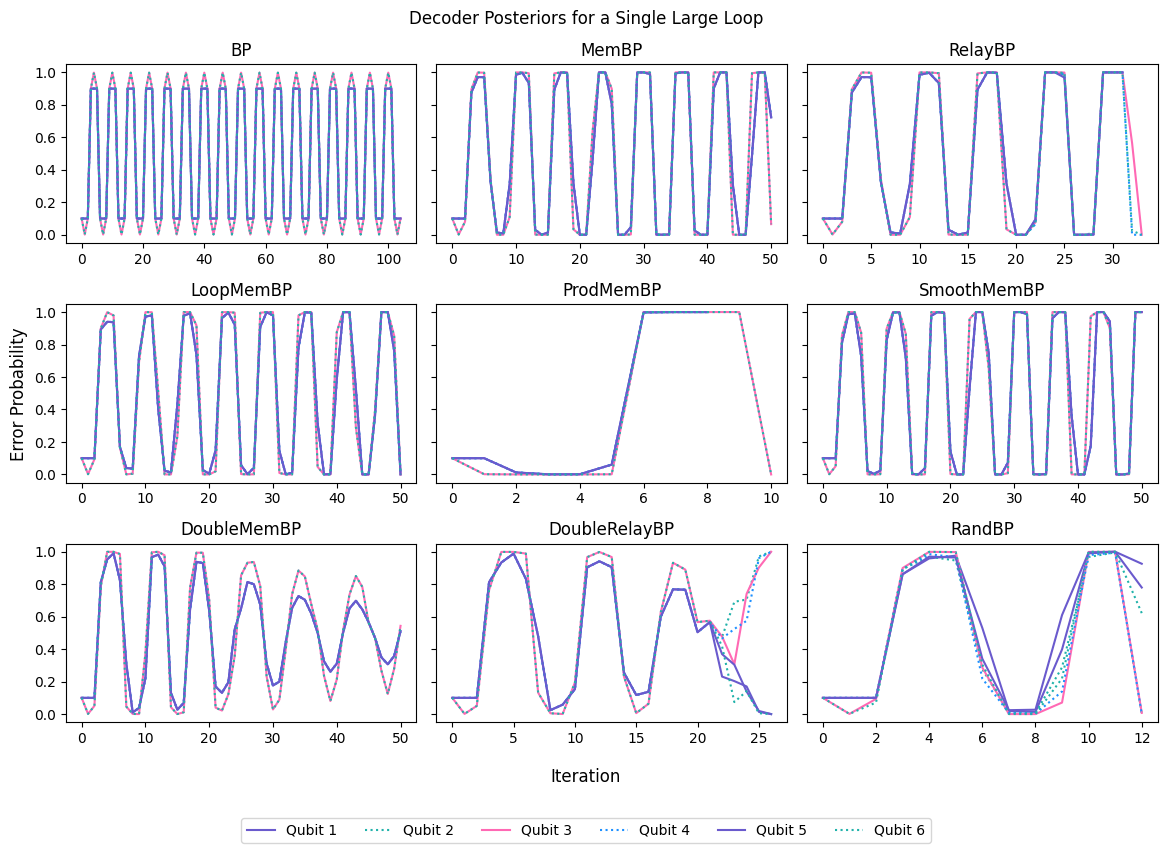

In [31]:
colours = ["slateblue", "lightseagreen", "hotpink", "dodgerblue", "slateblue", "lightseagreen"]
linestyles = ['-', ':', '-', ':', '-', ':']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8), sharey=True)
fig.suptitle('Decoder Posteriors for a Single Large Loop')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0, 0].set_title('BP')
axs[0, 1].set_title('MemBP')
axs[0, 2].set_title('RelayBP')
axs[1, 0].set_title('LoopMemBP')
axs[1, 1].set_title('ProdMemBP')
axs[1, 2].set_title('SmoothMemBP')
axs[2, 0].set_title('DoubleMemBP')
axs[2, 1].set_title('DoubleRelayBP')
axs[2, 2].set_title('RandBP')

for qubit in range(posteriors_bp.shape[1]):
    axs[0, 0].plot(posteriors_bp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit], label = f"Qubit {qubit+1}")
    axs[0, 1].plot(posteriors_mem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[0, 2].plot(posteriors_relay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 0].plot(posteriors_loopmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 1].plot(posteriors_prodmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 2].plot(posteriors_smoothmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 0].plot(posteriors_doublemem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 1].plot(posteriors_doublerelay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 2].plot(posteriors_randbp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])

fig.legend(loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.07))
fig.tight_layout()


## Almost Surface Code 9-Loop

In [ ]:
field = Field(2)
h = np.array([[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
              [0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1],
              [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1]
              ])
priors = np.array([[0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1]], dtype=float)
syndrome = np.array([1, 0, 0, 0, 0, 0, 0, 0, 1])
loopsize=3

c = 0.2
w = 0.5

bp = BP(field, h, priors, 103)
membp = RelayBP(field, h, priors, 50, 50, 1, 1, 0.2*np.ones((h.shape[1], field.p, 1)))

mem_weight = np.zeros((h.shape[1], field.p, 4))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 4 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 4, mem_weight)

loopmembp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)) / loopsize)
prodmembp = ProdRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))
smoothmembp = SmoothRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), loopsize)
doublemembp = DoubleRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), 1.3*np.ones((h.shape[1], field.p, 1)), loopsize)
doublerelaybp = DoubleRelayBP(field, h, priors, 10, 20, 3, 4, mem_weight, 2*np.ones((h.shape[1], field.p, 4)), loopsize)

rmem_weight = np.zeros((h.shape[1], field.p, 5))
rmem_weight[:, :, 0] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p))
rmem_weight[:, :, 2] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p))
rmem_weight[:, :, 4] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p))
randbp = RelayBP(field, h, priors, 20, 20, 3, 5, rmem_weight)


In [ ]:
error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, _, posteriors_mem = membp.decode(syndrome, debug=True, metric=True)
posteriors_mem = np.array(posteriors_mem)
print(f"MemBP succeeded: {success}")

error, success, _, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, _, posteriors_loopmem = loopmembp.decode(syndrome, debug=True, metric=True)
posteriors_loopmem = np.array(posteriors_loopmem)
print(f"LoopMemBP succeeded: {success}")

error, success, _, posteriors_prodmem = prodmembp.decode(syndrome, debug=True, metric=True)
posteriors_prodmem = np.array(posteriors_prodmem)
print(f"ProdMemBP succeeded: {success}")

error, success, _, posteriors_smoothmem = smoothmembp.decode(syndrome, debug=True, metric=True)
posteriors_smoothmem = np.array(posteriors_smoothmem)
print(f"SmoothMemBP succeeded: {success}")

error, success, _, posteriors_doublemem = doublemembp.decode(syndrome, debug=True, metric=True)
posteriors_doublemem = np.array(posteriors_doublemem)
print(f"DoubleMemBP succeeded: {success}")

error, success, _, posteriors_doublerelay = doublerelaybp.decode(syndrome, debug=True, metric=True)
posteriors_doublerelay = np.array(posteriors_doublerelay)
print(f"DoubleRelayBP succeeded: {success}")

error, success, _, posteriors_randbp = randbp.decode(syndrome, debug=True, metric=True)
posteriors_randbp = np.array(posteriors_randbp)
print(f"RandBP succeeded: {success}")


BP succeeded: False
MemBP succeeded: False
RelayBP succeeded: True
LoopMemBP succeeded: False
ProdMemBP succeeded: False
SmoothMemBP succeeded: False
DoubleMemBP succeeded: False
DoubleRelayBP succeeded: True
RandBP succeeded: True


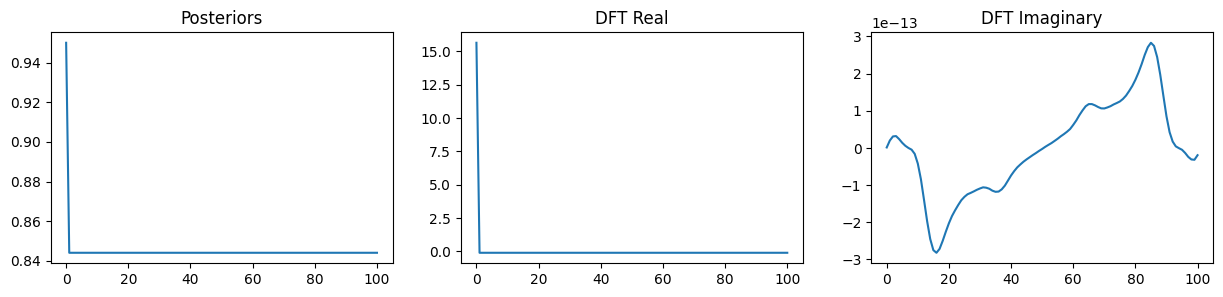

In [280]:
qubit = 4
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 3))

axs[0].plot(posteriors_bp[:, qubit, 0])
axs[1].plot(np.fft.fft(posteriors_bp[:, qubit, 1], axis=0).real)
axs[2].plot(np.fft.fft(posteriors_bp[:, qubit, 1], axis=0).imag)

axs[0].set_title("Posteriors")
axs[1].set_title("DFT Real")
axs[2].set_title("DFT Imaginary");


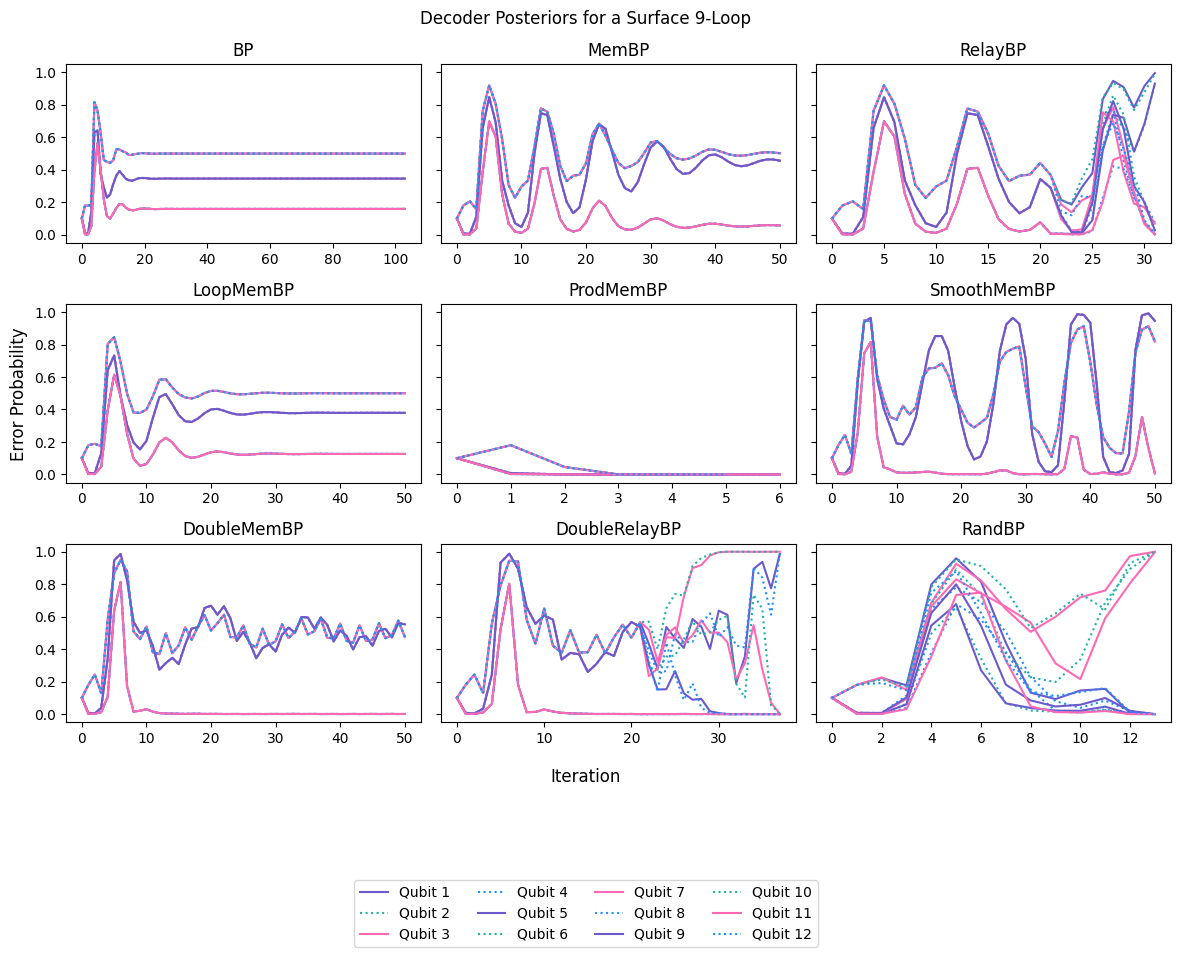

In [370]:
colours = ["slateblue", "lightseagreen", "hotpink", "dodgerblue", "slateblue", "lightseagreen", "hotpink", "dodgerblue", "slateblue", "lightseagreen", "hotpink", "dodgerblue"]
linestyles = ['-', ':', '-', ':', '-', ':', '-', ':', '-', ':', '-', ':']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8), sharey=True)
fig.suptitle('Decoder Posteriors for a Surface 9-Loop')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0, 0].set_title('BP')
axs[0, 1].set_title('MemBP')
axs[0, 2].set_title('RelayBP')
axs[1, 0].set_title('LoopMemBP')
axs[1, 1].set_title('ProdMemBP')
axs[1, 2].set_title('SmoothMemBP')
axs[2, 0].set_title('DoubleMemBP')
axs[2, 1].set_title('DoubleRelayBP')
axs[2, 2].set_title('RandBP')

for qubit in range(posteriors_bp.shape[1]):
    axs[0, 0].plot(posteriors_bp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit], label = f"Qubit {qubit+1}")
    axs[0, 1].plot(posteriors_mem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[0, 2].plot(posteriors_relay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 0].plot(posteriors_loopmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 1].plot(posteriors_prodmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 2].plot(posteriors_smoothmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 0].plot(posteriors_doublemem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 1].plot(posteriors_doublerelay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 2].plot(posteriors_randbp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])

fig.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.2))
fig.tight_layout()


In [ ]:
posteriors_bp[-1, :, 1]


array([0.5       , 0.15915338, 0.5       , 0.34594444, 0.15915338,
       0.34594444, 0.34594444, 0.15915338, 0.34594444, 0.5       ,
       0.15915338, 0.5       ])

In [ ]:
p = 0.1
tot = 2*p**8 + 4*p**6 + 6*p**4
dark = (p**8 + 2*p**6 + 3*p**4)/tot
light = (2*p**8 + 2*p**6 + p**4)/tot
green = (p**8 + 2*p**6 + 2*p**4)/tot

print(dark, light, green)


0.5 0.16890169199695376 0.3344425681268832


## Exhaustive Simulation

In [57]:
def process_exhaustive_results(results):
    new_results = {}
    for key, item in results.items():
        new_results[key] = 100 - 100*np.array(item)
    return new_results

@numba.njit
def generate_bin_errors(nqudits, weight):
    """Generate all binary errors of a given weight for nqudits qudits."""
    errors = []
    err = [0 for _ in range(nqudits)]
    for decimal in range(2**nqudits):
        index = 0
        for i in range(nqudits):
            val = decimal // (2**i) % 2
            err[i] = val
            if val:
                index += 1
        if index != weight:
            continue  # ideally would break out of two loops here :(
        errors.append(err.copy())
    return errors

def generate_errors(nqudits, weight, dim):
    bin_errors = generate_bin_errors(nqudits, weight)
    errors = []
    for error in bin_errors:
        error = np.array(error)
        vals = np.nonzero(error)[0]
        weight = len(vals)
        for ind in range((dim-1)**weight):
            new_error = error.copy()
            for i in range(weight):
                new_error[vals[i]] += (ind // ((dim-1)**i)) % (dim-1)
            errors.append(new_error)
    return errors
generate_errors(2, 2, 2)

def bin_weight_one(nqudits):
    errors = []
    mat = np.eye(nqudits, dtype=int)
    for err in mat:
        errors.append(err)
    return errors

def weight_one(nqudits, dim):
    weight=1
    bin_errors = bin_weight_one(nqudits)
    errors = []
    for error in bin_errors:
        error = np.array(error)
        vals = np.nonzero(error)[0]
        weight = len(vals)
        for ind in range((dim-1)**weight):
            new_error = error.copy()
            for i in range(weight):
                new_error[vals[i]] += (ind // ((dim-1)**i)) % (dim-1)
            errors.append(new_error)
    return errors

def bin_weight_two(nqudits):
    errors = []
    for shift in range(1, nqudits):
        mat = np.eye(nqudits, dtype=int)
        mat += np.eye(nqudits, k=shift, dtype=int)
        for ind, err in enumerate(mat):
            if ind >= nqudits - shift:
                break
            errors.append(err)
    return errors

def weight_two(nqudits, dim):
    weight=2
    bin_errors = bin_weight_two(nqudits)
    errors = []
    for error in bin_errors:
        error = np.array(error)
        vals = np.nonzero(error)[0]
        weight = len(vals)
        for ind in range((dim-1)**weight):
            new_error = error.copy()
            for i in range(weight):
                new_error[vals[i]] += (ind // ((dim-1)**i)) % (dim-1)
            errors.append(new_error)
    return errors

def bin_weight_three(nqudits):
    errors = []
    for shift_1 in range(1, nqudits):
        mat1 = np.eye(nqudits, dtype=int)
        mat1 += np.eye(nqudits, k=shift_1, dtype=int)
        for shift_2 in range(shift_1 + 1, nqudits):
            mat2 = mat1 + np.eye(nqudits, k=shift_2, dtype=int)
            for ind, err in enumerate(mat2):
                if ind >= nqudits - shift_2:
                    break
                errors.append(err)
    return errors

def weight_three(nqudits, dim):
    weight=3
    bin_errors = bin_weight_three(nqudits)
    errors = []
    for error in bin_errors:
        error = np.array(error)
        vals = np.nonzero(error)[0]
        weight = len(vals)
        for ind in range((dim-1)**weight):
            new_error = error.copy()
            for i in range(weight):
                new_error[vals[i]] += (ind // ((dim-1)**i)) % (dim-1)
            errors.append(new_error)
    return errors


In [68]:
d = 7
field = Field(5)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

bp_max_iter = 300

n_qudits = hx.shape[1]
weight = 1

# errors = generate_errors(n_qudits, weight, field.p)
errors = weight_two(n_qudits, field.p)
print(f'Number of errors: {len(errors)}')


Number of errors: 76048


In [69]:
p = 0.1
channel_prob_x = np.ones(n_qudits) * p
x_prior = np.zeros((n_qudits, field.p), dtype=float)

for i, prob in enumerate(channel_prob_x):
    x_prior[i, 0] = 1 - prob
    for j in range(1, field.p):
        x_prior[i, j] = prob / (field.p - 1)


In [70]:
failures = 0
fail_ind = []

print(f'Simulating all {len(errors)} errors...')
for ind, error in enumerate(errors):
    syndrome = (hx @ error) % field.p
    bp = BP(field, hx, x_prior, bp_max_iter)
    guessed_error, decoder_success, bp_success, posterior = bp.decode(syndrome, debug=True, metric=False)
    error_difference = (error - guessed_error) % field.p
    logical_effect = (np.array(lx) @ error_difference) % field.p

    if (np.any(logical_effect != 0)) or not decoder_success:
        failures += 1
        fail_ind.append(ind)

    if (ind % 100 == 0) and ind != 0:
        print(f'UPDATE: Completed {ind}/{len(errors)} with {failures} fails and rate {failures/ind}')

print(f'Total failures = {failures}/{len(errors)}')
print(f'Failed error indices = {fail_ind}')
    

Simulating all 76048 errors...
UPDATE: Completed 100/76048 with 24 fails and rate 0.24
UPDATE: Completed 200/76048 with 46 fails and rate 0.23
UPDATE: Completed 300/76048 with 68 fails and rate 0.22666666666666666
UPDATE: Completed 400/76048 with 88 fails and rate 0.22
UPDATE: Completed 500/76048 with 109 fails and rate 0.218
UPDATE: Completed 600/76048 with 130 fails and rate 0.21666666666666667
UPDATE: Completed 700/76048 with 152 fails and rate 0.21714285714285714
UPDATE: Completed 800/76048 with 168 fails and rate 0.21
UPDATE: Completed 900/76048 with 168 fails and rate 0.18666666666666668
UPDATE: Completed 1000/76048 with 168 fails and rate 0.168
UPDATE: Completed 1100/76048 with 168 fails and rate 0.15272727272727274
UPDATE: Completed 1200/76048 with 168 fails and rate 0.14
UPDATE: Completed 1300/76048 with 168 fails and rate 0.12923076923076923
UPDATE: Completed 1400/76048 with 168 fails and rate 0.12
UPDATE: Completed 1500/76048 with 168 fails and rate 0.112
UPDATE: Completed 1

In [71]:
results_toric_3 = {
    2 : [0/18, 72/153, 756/816],
    3 : [0/36, 180/612, 4572/6528],
    5 : [0/72, 504/2448, 28584/52224],
    7 : [0/108, 972/5508],
    11 : [0/180, 2340/15300]
}
print(results_toric_3)

results_toric_5 = {
    2 : [0/50, 150/1225, 5450/19600],
    3 : [0/100, 300/4900],
    5 : [0/200, 600/19600],
    7 : [0/300, 900/44100],
    11 : [0/500, 1500/122500]
}
print(results_toric_5)

results_toric_7 = {
    2 : [0/98, 294/4753],
    3 : [0/196, 588/19012],
    5 : [0/392, 1176/76048],
    7 : [0/588],
    11 : [0/980]
}
print(results_toric_7)


{2: [0.0, 0.47058823529411764, 0.9264705882352942], 3: [0.0, 0.29411764705882354, 0.7003676470588235], 5: [0.0, 0.20588235294117646, 0.5473345588235294], 7: [0.0, 0.17647058823529413], 11: [0.0, 0.15294117647058825]}
{2: [0.0, 0.12244897959183673, 0.2780612244897959], 3: [0.0, 0.061224489795918366], 5: [0.0, 0.030612244897959183], 7: [0.0, 0.02040816326530612], 11: [0.0, 0.012244897959183673]}
{2: [0.0, 0.061855670103092786], 3: [0.0, 0.030927835051546393], 5: [0.0, 0.015463917525773196], 7: [0.0], 11: [0.0]}


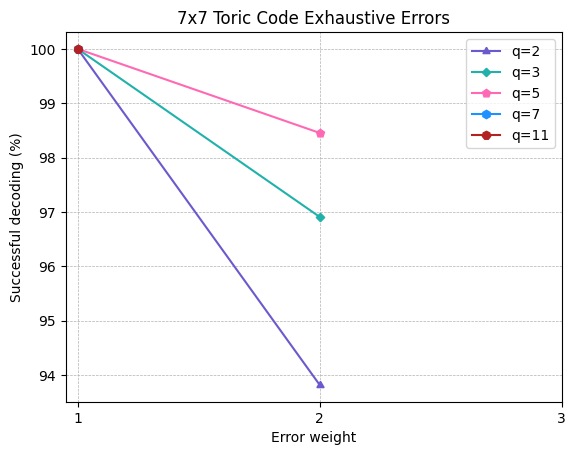

In [72]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='q=2'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='q=3'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='q=5'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='q=7'),
    Line2D([0], [0], color='firebrick', marker=(7, 0, 0), linestyle='-', label='q=11')
]

physical_error = [1, 2]
plot_results = process_exhaustive_results(results_toric_7)

fig, ax = plt.subplots()

ax.plot(plot_results[2], color='slateblue', marker=(3, 0, 0))
ax.plot(plot_results[3], color='lightseagreen', marker=(4, 0, 0))
ax.plot(plot_results[5], color='hotpink', marker=(5, 0, 0))
ax.plot(plot_results[7], color='dodgerblue', marker=(6, 0, 0))
ax.plot(plot_results[11], color='firebrick', marker=(7, 0, 0))

plt.xticks([0, 1, 2], ['1', '2', '3'])
ax.set_xlabel('Error weight')
ax.set_ylabel('Successful decoding (%)')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('7x7 Toric Code Exhaustive Errors');


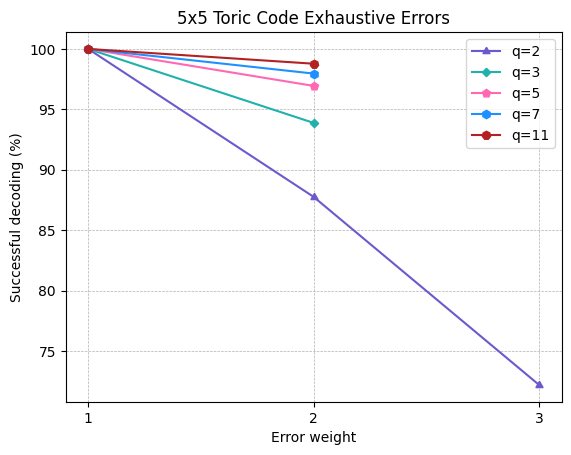

In [9]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='q=2'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='q=3'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='q=5'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='q=7'),
    Line2D([0], [0], color='firebrick', marker=(7, 0, 0), linestyle='-', label='q=11')
]

physical_error = [1, 2]
plot_results = process_exhaustive_results(results_toric_5)

fig, ax = plt.subplots()

ax.plot(plot_results[2], color='slateblue', marker=(3, 0, 0))
ax.plot(plot_results[3], color='lightseagreen', marker=(4, 0, 0))
ax.plot(plot_results[5], color='hotpink', marker=(5, 0, 0))
ax.plot(plot_results[7], color='dodgerblue', marker=(6, 0, 0))
ax.plot(plot_results[11], color='firebrick', marker=(7, 0, 0))

plt.xticks([0, 1, 2], ['1', '2', '3'])
ax.set_xlabel('Error weight')
ax.set_ylabel('Successful decoding (%)')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('5x5 Toric Code Exhaustive Errors');


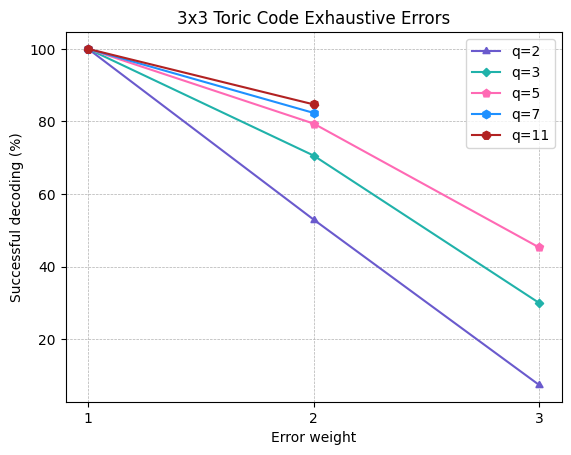

In [24]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='q=2'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='q=3'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='q=5'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='q=7'),
    Line2D([0], [0], color='firebrick', marker=(7, 0, 0), linestyle='-', label='q=11')
]

physical_error = [1, 2]
plot_results = process_exhaustive_results(results_toric_3)

fig, ax = plt.subplots()

ax.plot(plot_results[2], color='slateblue', marker=(3, 0, 0))
ax.plot(plot_results[3], color='lightseagreen', marker=(4, 0, 0))
ax.plot(plot_results[5], color='hotpink', marker=(5, 0, 0))
ax.plot(plot_results[7], color='dodgerblue', marker=(6, 0, 0))
ax.plot(plot_results[11], color='firebrick', marker=(7, 0, 0))

plt.xticks([0, 1, 2], ['1', '2', '3'])
ax.set_xlabel('Error weight')
ax.set_ylabel('Successful decoding (%)')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('3x3 Toric Code Exhaustive Errors');


## Simulation

In [2]:
d = 5
field = Field(2)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

p = 0.03
num_trials = 3000

bp_max_iter = 300

max_iter = 60
first_iter = 80
solutions = 1
relays = 10

c = 0.05
w = 0.2

loopsize = 1


In [41]:
physical_error = np.logspace(-0.7, -1.8, 10)
num_failures = [10 for _ in range(10)]
physical_error


array([0.19952623, 0.15058364, 0.11364637, 0.08576959, 0.06473082,
       0.04885274, 0.03686945, 0.02782559, 0.02100014, 0.01584893])

In [42]:
def decode(failures, ind, results, trials, decoder, syndrome, error, field, lx, num_failures, s):
    if failures < num_failures[ind]:
        guessed_error, decoder_success, bp_success, posterior = decoder.decode(syndrome, debug=True, metric=False)
        error_difference = (error - guessed_error) % field.p
        logical_effect = (np.array(lx) @ error_difference) % field.p

        if np.any(logical_effect != 0):
            failures += 1

        if failures == num_failures[ind]:
            results.append(trials)
            print(f'Completed {s}: {trials}')
    return failures, results


In [43]:
print(f'Simulation for error rates {physical_error}')

results_rust = []
results_relaybp = []
results_fixrelaybp = []
results_bposd = []
results_bp = []
results_membp = []
results_smoothrelay = []
results_doublerelay = []
results_randbp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.2f}')

    n_qudits = hx.shape[1]
    channel_prob_x = np.ones(n_qudits) * p
    x_prior = np.zeros((n_qudits, field.p), dtype=float)

    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_rust = 0
    failures_relaybp = 0
    failures_fixrelaybp = 0
    failures_bposd = 0
    failures_bp = 0
    failures_membp = 0
    failures_smoothrelay = 0
    failures_doublerelay = 0
    failures_randbp = 0
    failures = sum([failures_rust, failures_relaybp, failures_bposd, failures_bp, failures_membp, failures_smoothrelay, failures_doublerelay, failures_randbp, failures_fixrelaybp])

    trials = 0

    while failures < 3 * num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = c
        mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p, relays - 1))

        rmem_weight = np.zeros((n_qudits, field.p, relays))
        rmem_weight[:, :, 0] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p))
        rmem_weight[:, :, 2] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p))
        rmem_weight[:, :, 4] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p))
        rmem_weight[:, :, 6] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p))
        rmem_weight[:, :, 8] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p))

        fmem_weight = np.zeros((n_qudits, field.p, relays))
        fmem_weight[:, :, 0] = c
        mem = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p-1, relays - 1))
        fmem_weight[:, 1:, 1:] = mem
        fmem_weight[:, 0:1, 1:] = mem

        # Generate syndrome
        error = np.zeros(n_qudits, dtype=int)
        error_mask = np.random.rand(n_qudits) < p
        for i in np.where(error_mask)[0]:
            error[i] = np.random.randint(1, field.p)
        syndrome = (hx @ error) % field.p

        # Decode
        failures_relaybp, results_relaybp = decode(failures_relaybp, ind, results_relaybp, trials, RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight), syndrome, error, field, lx, num_failures, 'RelayBP')
        failures_fixrelaybp, results_fixrelaybp = decode(failures_fixrelaybp, ind, results_fixrelaybp, trials, RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=fmem_weight), syndrome, error, field, lx, num_failures, 'FixRelayBP')
        # failures_bposd, results_bposd = decode(failures_bposd, ind, results_bposd, trials, BPOSD(field, hx, x_prior, bp_max_iter), syndrome, error, field, lx, num_failures, 'BPOSD')
        # failures_bp, results_bp = decode(failures_bp, ind, results_bp, trials, BP(field, hx, x_prior, bp_max_iter), syndrome, error, field, lx, num_failures, 'BP')
        # failures_membp, results_membp = decode(failures_membp, ind, results_membp, trials, RelayBP(field, hx, x_prior, 50, 50, 1, 1, 0.2*np.ones((hx.shape[1], field.p, 1))), syndrome, error, field, lx, num_failures, 'MemBP')
        # failures_smoothrelay, results_smoothrelay = decode(failures_smoothrelay, ind, results_smoothrelay, trials, SmoothRelayBP(field, hx, x_prior, 10, 20, 3, 4, c*np.ones((hx.shape[1], field.p, 4)), loopsize), syndrome, error, field, lx, num_failures, 'SmoothRelay')
        # failures_doublerelay, results_doublerelay = decode(failures_doublerelay, ind, results_doublerelay, trials, DoubleRelayBP(field, hx, x_prior, 10, 20, 3, 4, mem_weight, 2*np.ones((hx.shape[1], field.p, 4)), loopsize), syndrome, error, field, lx, num_failures, 'DoubleRelay')
        # failures_randbp, results_randbp = decode(failures_randbp, ind, results_randbp, trials, RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=max_iter, solutions=solutions, relays=relays, mem_weight=rmem_weight), syndrome, error, field, lx, num_failures, 'RandBP')

        if failures_rust < num_failures[ind]:
            rustrelaybp = RelayDecoderF32(hx, error_priors=channel_prob_x, gamma0=c, pre_iter=20, num_sets=4, set_max_iter=10, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)
            syndrome = syndrome.astype(np.uint8)
            guessed_error = rustrelaybp.decode(syndrome)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_rust += 1

            if failures_rust == num_failures[ind]:
                results_rust.append(trials)
                print(f'Completed RustRelayBP: {trials}')

        if trials % 100 == 0:
            print(f'UPDATE: {trials} trials reached.')

        failures = sum([failures_rust, failures_relaybp, failures_bposd, failures_bp, failures_membp, failures_smoothrelay, failures_doublerelay, failures_randbp, failures_fixrelaybp])
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.19952623 0.15058364 0.11364637 0.08576959 0.06473082 0.04885274
 0.03686945 0.02782559 0.02100014 0.01584893]
Starting trials for p=0.20
Completed RustRelayBP: 15
Completed RelayBP: 20
Completed FixRelayBP: 20
[1/10]
Starting trials for p=0.15
Completed RelayBP: 16
Completed FixRelayBP: 20
Completed RustRelayBP: 20
[2/10]
Starting trials for p=0.11
Completed RelayBP: 28
Completed RustRelayBP: 28
Completed FixRelayBP: 29
[3/10]
Starting trials for p=0.09
Completed RustRelayBP: 57
Completed FixRelayBP: 74
Completed RelayBP: 77
[4/10]
Starting trials for p=0.06
Completed RustRelayBP: 79
Completed RelayBP: 156
Completed FixRelayBP: 156
[5/10]
Starting trials for p=0.05
UPDATE: 100 trials reached.
Completed RustRelayBP: 145
Completed RelayBP: 172
Completed FixRelayBP: 172
[6/10]
Starting trials for p=0.04
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
Completed RustRelayBP: 311
Completed RelayBP: 468
Completed FixRelayBP: 46

In [ ]:
results = {'rust' : results_rust, 'relaybp' : results_relaybp, 'frelay' : results_fixrelaybp}


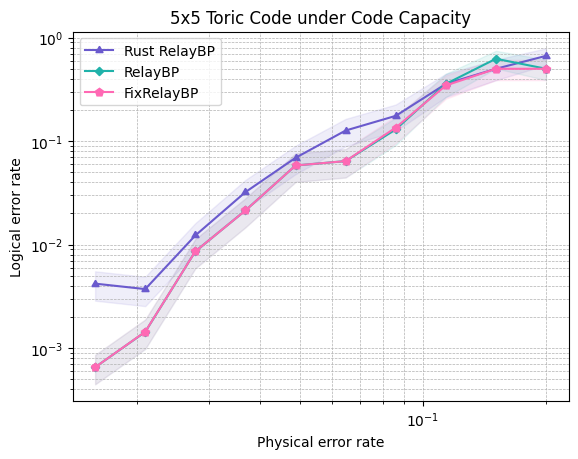

In [45]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='FixRelayBP')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results, {'rust':10, 'relaybp':10, 'frelay':10}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results['rust'], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results['relaybp'], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results['frelay'], color='hotpink', marker=(5, 0, 0))
ax.fill_between(physical_error, plot_results['rust'] - plot_errors['rust'], plot_results['rust'] + plot_errors['rust'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['relaybp'] - plot_errors['relaybp'], plot_results['relaybp'] + plot_errors['relaybp'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results['frelay'] - plot_errors['frelay'], plot_results['frelay'] + plot_errors['frelay'], color='hotpink', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('5x5 Toric Code under Code Capacity');


In [ ]:
results_5 = {'rust' : results_rust, 'relaybp' : results_relaybp, 'bposd' : results_bposd, 'bp' : results_bp, 'membp' : results_membp, 'smooth' : results_smoothrelay, 'double' : results_doublerelay, 'randbp' : results_randbp}


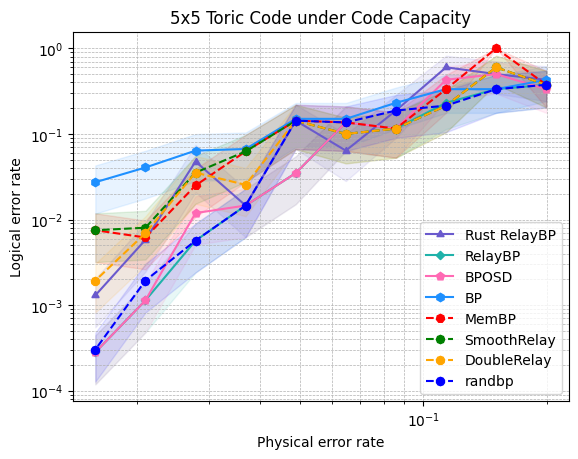

In [102]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP'),
    Line2D([0], [0], color='red', marker=(7, 0, 0), linestyle='--', label='MemBP'),
    Line2D([0], [0], color='green', marker=(8, 0, 0), linestyle='--', label='SmoothRelay'),
    Line2D([0], [0], color='orange', marker=(9, 0, 0), linestyle='--', label='DoubleRelay'),
    Line2D([0], [0], color='blue', marker=(10, 0, 0), linestyle='--', label='randbp')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results_5, {'rust':3, 'relaybp':3, 'bposd':3, 'bp':3, 'membp':3, 'smooth':3, 'double':3, 'randbp':3}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results['rust'], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results['relaybp'], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results['bposd'], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results['bp'], color='dodgerblue', marker=(6, 0, 0))
ax.loglog(physical_error, plot_results['membp'], color='red', marker=(7, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['smooth'], color='green', marker=(8, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['double'], color='orange', marker=(9, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['randbp'], color='blue', marker=(10, 0, 0), linestyle="--")
ax.fill_between(physical_error, plot_results['rust'] - plot_errors['rust'], plot_results['rust'] + plot_errors['rust'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['relaybp'] - plot_errors['relaybp'], plot_results['relaybp'] + plot_errors['relaybp'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results['bposd'] - plot_errors['bposd'], plot_results['bposd'] + plot_errors['bposd'], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results['bp'] - plot_errors['bp'], plot_results['bp'] + plot_errors['bp'], color='dodgerblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['membp'] - plot_errors['membp'], plot_results['membp'] + plot_errors['membp'], color='red', alpha=alpha)
ax.fill_between(physical_error, plot_results['smooth'] - plot_errors['smooth'], plot_results['smooth'] + plot_errors['smooth'], color='green', alpha=alpha)
ax.fill_between(physical_error, plot_results['double'] - plot_errors['double'], plot_results['double'] + plot_errors['double'], color='orange', alpha=alpha)
ax.fill_between(physical_error, plot_results['randbp'] - plot_errors['randbp'], plot_results['randbp'] + plot_errors['randbp'], color='blue', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('5x5 Toric Code under Code Capacity');


In [7]:
results_7 = {'rust' : results_rust, 'relaybp' : results_relaybp, 'bposd' : results_bposd, 'bp' : results_bp, 'membp' : results_membp, 'smooth' : results_smoothrelay, 'double' : results_doublerelay}
print(results_7.__repr__())


{'rust': [12, 16, 20, 45, 93, 141, 527, 703, 1462, 969], 'relaybp': [14, 15, 33, 68, 217, 781, 1651, 8928, 25748, 134171], 'bposd': [19, 19, 29, 130, 223, 812, 1651, 10143, 28751, 134171], 'bp': [15, 14, 23, 31, 83, 86, 306, 134, 985, 465], 'membp': [14, 14, 33, 81, 161, 292, 555, 1302, 1731, 815], 'smooth': [15, 14, 24, 52, 106, 321, 347, 621, 1932, 1153], 'double': [19, 14, 29, 52, 106, 292, 395, 855, 6930, 18592]}


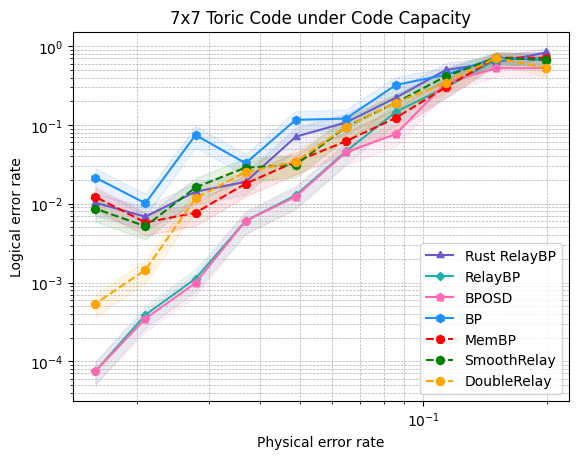

In [9]:
# results_7 = {}

legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP'),
    Line2D([0], [0], color='red', marker=(7, 0, 0), linestyle='--', label='MemBP'),
    Line2D([0], [0], color='green', marker=(8, 0, 0), linestyle='--', label='SmoothRelay'),
    Line2D([0], [0], color='orange', marker=(9, 0, 0), linestyle='--', label='DoubleRelay')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results_7, {'rust':10, 'relaybp':10, 'bposd':10, 'bp':10, 'membp':10, 'smooth':10, 'double':10}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results['rust'], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results['relaybp'], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results['bposd'], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results['bp'], color='dodgerblue', marker=(6, 0, 0))
ax.loglog(physical_error, plot_results['membp'], color='red', marker=(7, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['smooth'], color='green', marker=(8, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['double'], color='orange', marker=(9, 0, 0), linestyle="--")
ax.fill_between(physical_error, plot_results['rust'] - plot_errors['rust'], plot_results['rust'] + plot_errors['rust'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['relaybp'] - plot_errors['relaybp'], plot_results['relaybp'] + plot_errors['relaybp'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results['bposd'] - plot_errors['bposd'], plot_results['bposd'] + plot_errors['bposd'], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results['bp'] - plot_errors['bp'], plot_results['bp'] + plot_errors['bp'], color='dodgerblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['membp'] - plot_errors['membp'], plot_results['membp'] + plot_errors['membp'], color='red', alpha=alpha)
ax.fill_between(physical_error, plot_results['smooth'] - plot_errors['smooth'], plot_results['smooth'] + plot_errors['smooth'], color='green', alpha=alpha)
ax.fill_between(physical_error, plot_results['double'] - plot_errors['double'], plot_results['double'] + plot_errors['double'], color='orange', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('7x7 Toric Code under Code Capacity');


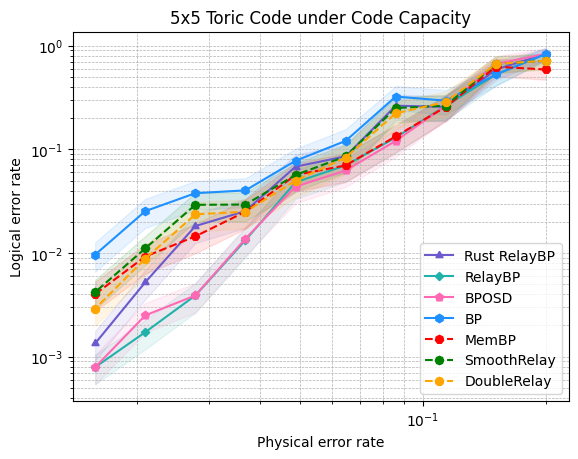

In [18]:
results_5 = {'rust': [12, 17, 39, 38, 117, 147, 394, 550, 1916, 7445], 'relaybp': [12, 19, 38, 77, 143, 208, 753, 2567, 5800, 12622], 'bposd': [12, 15, 38, 83, 160, 229, 727, 2567, 3997, 12622], 'bp': [12, 19, 34, 31, 83, 129, 249, 265, 395, 1038], 'membp': [17, 16, 39, 75, 143, 177, 400, 691, 1082, 2492], 'smooth': [14, 15, 38, 40, 117, 177, 341, 343, 903, 2384], 'double': [14, 15, 35, 45, 120, 201, 400, 424, 1133, 3442]}

legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP'),
    Line2D([0], [0], color='red', marker=(7, 0, 0), linestyle='--', label='MemBP'),
    Line2D([0], [0], color='green', marker=(8, 0, 0), linestyle='--', label='SmoothRelay'),
    Line2D([0], [0], color='orange', marker=(9, 0, 0), linestyle='--', label='DoubleRelay')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results_5, {'rust':10, 'relaybp':10, 'bposd':10, 'bp':10, 'membp':10, 'smooth':10, 'double':10}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results['rust'], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results['relaybp'], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results['bposd'], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results['bp'], color='dodgerblue', marker=(6, 0, 0))
ax.loglog(physical_error, plot_results['membp'], color='red', marker=(7, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['smooth'], color='green', marker=(8, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['double'], color='orange', marker=(9, 0, 0), linestyle="--")
ax.fill_between(physical_error, plot_results['rust'] - plot_errors['rust'], plot_results['rust'] + plot_errors['rust'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['relaybp'] - plot_errors['relaybp'], plot_results['relaybp'] + plot_errors['relaybp'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results['bposd'] - plot_errors['bposd'], plot_results['bposd'] + plot_errors['bposd'], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results['bp'] - plot_errors['bp'], plot_results['bp'] + plot_errors['bp'], color='dodgerblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['membp'] - plot_errors['membp'], plot_results['membp'] + plot_errors['membp'], color='red', alpha=alpha)
ax.fill_between(physical_error, plot_results['smooth'] - plot_errors['smooth'], plot_results['smooth'] + plot_errors['smooth'], color='green', alpha=alpha)
ax.fill_between(physical_error, plot_results['double'] - plot_errors['double'], plot_results['double'] + plot_errors['double'], color='orange', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('5x5 Toric Code under Code Capacity');


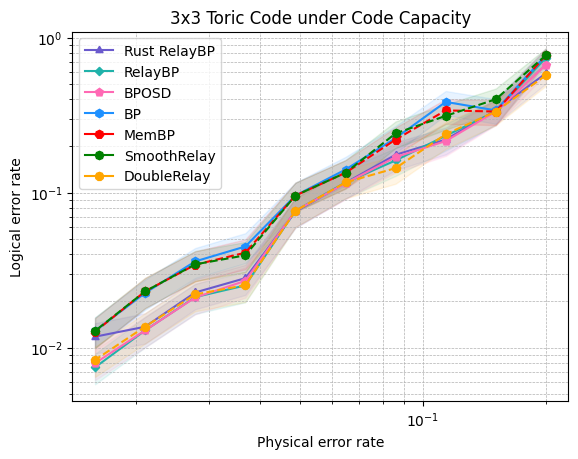

In [ ]:
results_3 = {'rust': [34, 59, 91, 114, 173, 265, 712, 880, 1464, 1697], 'relaybp': [27, 60, 86, 124, 172, 262, 793, 943, 1546, 2675], 'bposd': [30, 60, 93, 118, 174, 262, 741, 948, 1546, 2515], 'bp': [26, 59, 52, 89, 142, 209, 445, 555, 887, 1559], 'membp': [26, 60, 59, 91, 149, 209, 488, 583, 866, 1576], 'smooth': [26, 50, 64, 83, 149, 209, 507, 580, 866, 1559], 'double': [35, 60, 84, 139, 172, 262, 790, 906, 1461, 2399]}

legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP'),
    Line2D([0], [0], color='red', marker=(7, 0, 0), linestyle='-', label='MemBP'),
    Line2D([0], [0], color='green', marker=(8, 0, 0), linestyle='-', label='SmoothRelay'),
    Line2D([0], [0], color='orange', marker=(9, 0, 0), linestyle='-', label='DoubleRelay')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results_3, {'rust':20, 'relaybp':20, 'bposd':20, 'bp':20, 'membp':20, 'smooth':20, 'double':20}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results['rust'], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results['relaybp'], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results['bposd'], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results['bp'], color='dodgerblue', marker=(6, 0, 0))
ax.loglog(physical_error, plot_results['membp'], color='red', marker=(7, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['smooth'], color='green', marker=(8, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['double'], color='orange', marker=(9, 0, 0), linestyle="--")
ax.fill_between(physical_error, plot_results['rust'] - plot_errors['rust'], plot_results['rust'] + plot_errors['rust'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['relaybp'] - plot_errors['relaybp'], plot_results['relaybp'] + plot_errors['relaybp'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results['bposd'] - plot_errors['bposd'], plot_results['bposd'] + plot_errors['bposd'], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results['bp'] - plot_errors['bp'], plot_results['bp'] + plot_errors['bp'], color='dodgerblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['membp'] - plot_errors['membp'], plot_results['membp'] + plot_errors['membp'], color='red', alpha=alpha)
ax.fill_between(physical_error, plot_results['smooth'] - plot_errors['smooth'], plot_results['smooth'] + plot_errors['smooth'], color='green', alpha=alpha)
ax.fill_between(physical_error, plot_results['double'] - plot_errors['double'], plot_results['double'] + plot_errors['double'], color='orange', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('3x3 Toric Code under Code Capacity');
